# Predicting the CO2 Emissions from a Vehicle using Machine Learning

The Framework I will be following:

1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

> The goal is to predict the CO2 Emissions from a Vehicle using Scikit-Learn's Regression Models, given information on vehicle specifications, and labelled CO2 emmisions.

## 2. Data
The data is downloaded from Kaggle - https://www.kaggle.com/datasets/brsahan/vehicle-co2-emissions-dataset?resource=download

## 3. Evaluation

> The goal for this project is to build a Machine Learning model which minimizes the R^2 (R-squared value /  coefficient of determination) as well as evaluating on other metrics too like MAE (mean absolute error) and MSE (mean squared error)

## 4. Features
**Data Dictionary**

1. Make: Vehicle brand or manufacturer
2. Model: Specific model of vehicle
3. Vehicle Class: Class of vehicle depending on their utility, capacity and weight
4. Engine Size (L): Engine size in litres
5. Cylinders: Number of cylinders in the engine
6. Transmission: Transmission type with number of gears
    * A = Automatic
    * AM = Automated manual
    * AS = Automatic with select shift
    * AV = Continuously variable
    * M = Manual
    * 3 - 10 = Number of gears

7. Fuel Type: Type of Fuel used
    * X = Regular gasoline
    * Z = Premium gasoline
    * D = Diesel
    * E = Ethanol (E85)
    * N = Natural gas

8. Fuel Consumption City (L/100 km): Fuel consumption in city roads (L / 100 KM)
9. Fuel Consumption Hwy (L/100 km): Fuel consumption in highways (L / 100 KM)
10. Fuel Consumption Comb (L/100 km): Combined city and highway Fuel consumption (L / 100 KM)
11. Fuel Consumption Comb (mpg): Combined city and highway Fuel consumption in miles per galon (mpg)
12. CO2 Emissions(g/km): The tailpipe emissions of carbon dioxide (in grams per kilometre) for combined city and highway driving   

In [72]:
# Importing tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("co2.csv")
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### EDA (Exploratory Data Analysis)

In [3]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

In [5]:
df.shape

(7385, 12)

In [6]:
df.isna().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [9]:
df["Vehicle Class"].value_counts()

Vehicle Class
SUV - SMALL                 1217
MID-SIZE                    1133
COMPACT                     1022
SUV - STANDARD               735
FULL-SIZE                    639
SUBCOMPACT                   606
PICKUP TRUCK - STANDARD      538
TWO-SEATER                   460
MINICOMPACT                  326
STATION WAGON - SMALL        252
PICKUP TRUCK - SMALL         159
MINIVAN                       80
SPECIAL PURPOSE VEHICLE       77
VAN - PASSENGER               66
STATION WAGON - MID-SIZE      53
VAN - CARGO                   22
Name: count, dtype: int64

In [10]:
df["Make"].value_counts()

Make
FORD             628
CHEVROLET        588
BMW              527
MERCEDES-BENZ    419
PORSCHE          376
TOYOTA           330
GMC              328
AUDI             286
NISSAN           259
JEEP             251
DODGE            246
KIA              231
HONDA            214
HYUNDAI          210
MINI             204
VOLKSWAGEN       197
MAZDA            180
LEXUS            178
JAGUAR           160
CADILLAC         158
SUBARU           140
VOLVO            124
INFINITI         108
BUICK            103
RAM               97
LINCOLN           96
MITSUBISHI        95
CHRYSLER          88
LAND ROVER        85
FIAT              73
ACURA             72
MASERATI          61
ROLLS-ROYCE       50
ASTON MARTIN      47
BENTLEY           46
LAMBORGHINI       41
ALFA ROMEO        30
GENESIS           25
SCION             22
SMART              7
BUGATTI            3
SRT                2
Name: count, dtype: int64

In [12]:
df["Model"].value_counts()

Model
F-150 FFV                                 32
F-150 FFV 4X4                             32
MUSTANG                                   27
FOCUS FFV                                 24
SONIC                                     20
                                          ..
Highlander Hybrid AWD Limited/Platinum     1
RAV4 AWD TRD Off-Road                      1
Tacoma 4WD D-Cab TRD Off-Road/Pro          1
Atlas Cross Sport 4MOTION                  1
XC40 T4 AWD                                1
Name: count, Length: 2053, dtype: int64

In [13]:
df["Transmission"].value_counts()

Transmission
AS6     1324
AS8     1211
M6       901
A6       789
A8       490
AM7      445
A9       339
AS7      319
AV       295
M5       193
AS10     168
AM6      132
AV7      118
AV6      113
M7        91
A5        84
AS9       77
A4        65
AM8       62
A7        53
AV8       39
A10       31
AS5       26
AV10      11
AM5        4
AM9        3
AS4        2
Name: count, dtype: int64

In [14]:
df["Fuel Type"].value_counts()

Fuel Type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64

In [15]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [19]:
# To find the average emissions from each car company
emissions_per_make = df.groupby(df["Make"], as_index = False).agg(average_emission = ("CO2 Emissions(g/km)", "mean"))
emissions_per_make.sort_values("average_emission",
                                ascending = False)

,Make,average_emission
6,BUGATTI,522.000000
22,LAMBORGHINI,400.780488
37,SRT,389.000000
34,ROLLS-ROYCE,388.480000
4,BENTLEY,362.934783
2,ASTON MARTIN,339.617021
26,MASERATI,318.147541
15,GMC,299.917683
33,RAM,292.402062
23,LAND ROVER,287.647059


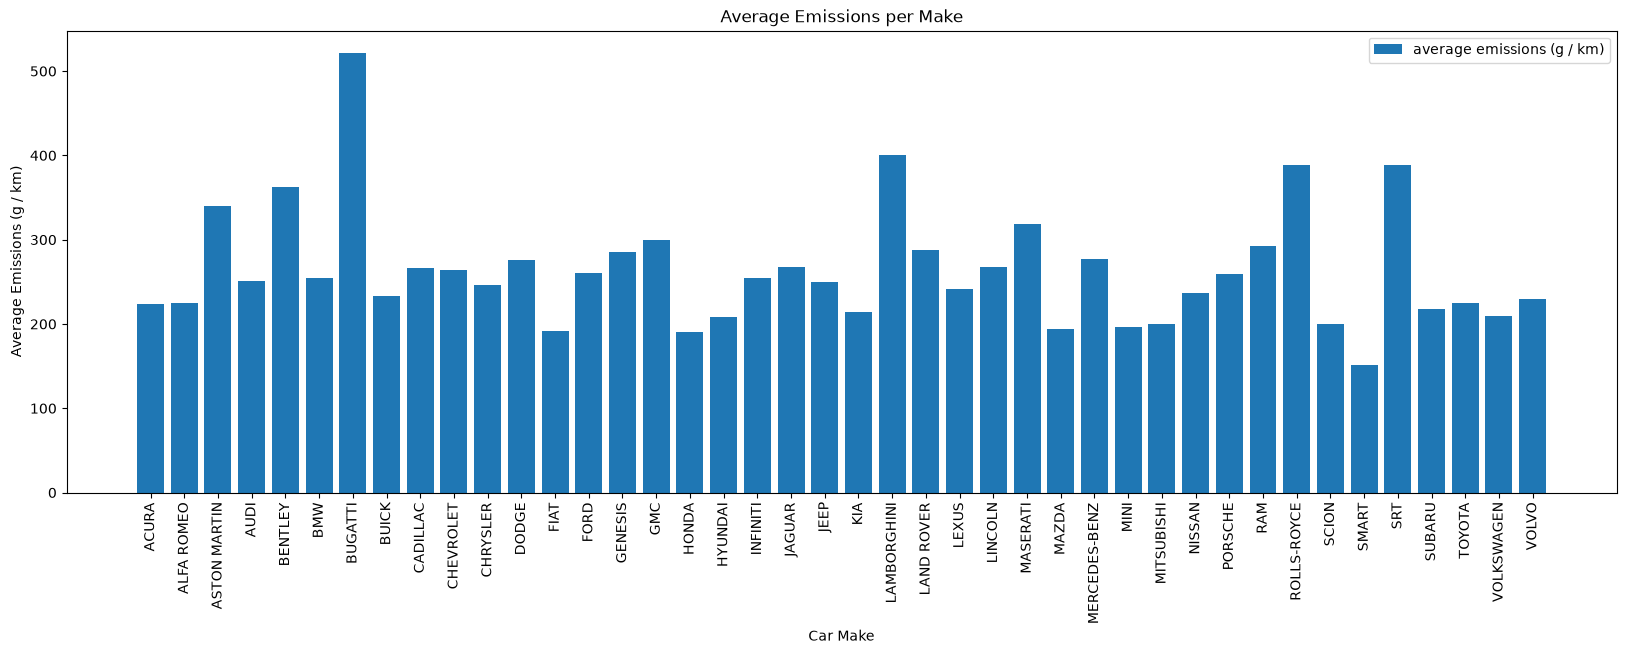

In [45]:
fig, ax = plt.subplots(figsize = (20, 6))
ax.bar(emissions_per_make["Make"],
        emissions_per_make["average_emission"])
ax.tick_params(axis = "x",
               labelrotation = 90)
ax.set(xlabel = "Car Make",
       ylabel = "Average Emissions (g / km)",
       title = "Average Emissions per Make")
ax.legend(["average emissions (g / km)"]);

We can infer that bugatti has the highest average emissions compared to other car companies

In [35]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [36]:
df["Fuel Type"].value_counts()

Fuel Type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64

In [91]:
# Check average emissions for each fuel type
emissions_per_fueltype = df.groupby(df["Fuel Type"], as_index = False).agg(average_emission_per_fueltype = ("CO2 Emissions(g/km)", "mean"))
emissions_per_fueltype.sort_values("average_emission_per_fueltype", ascending = False, ignore_index = True)

,Fuel Type,average_emission_per_fueltype
0,E,275.091892
1,Z,266.043410
2,D,237.548571
3,X,235.119329
4,N,213.000000


Fuel Type: Type of Fuel used

* X = Regular gasoline
* Z = Premium gasoline
* D = Diesel
* E = Ethanol (E85)
* N = Natural gas

> Ethanol has the highest average CO2 emissions while Natural Gas has the lowest

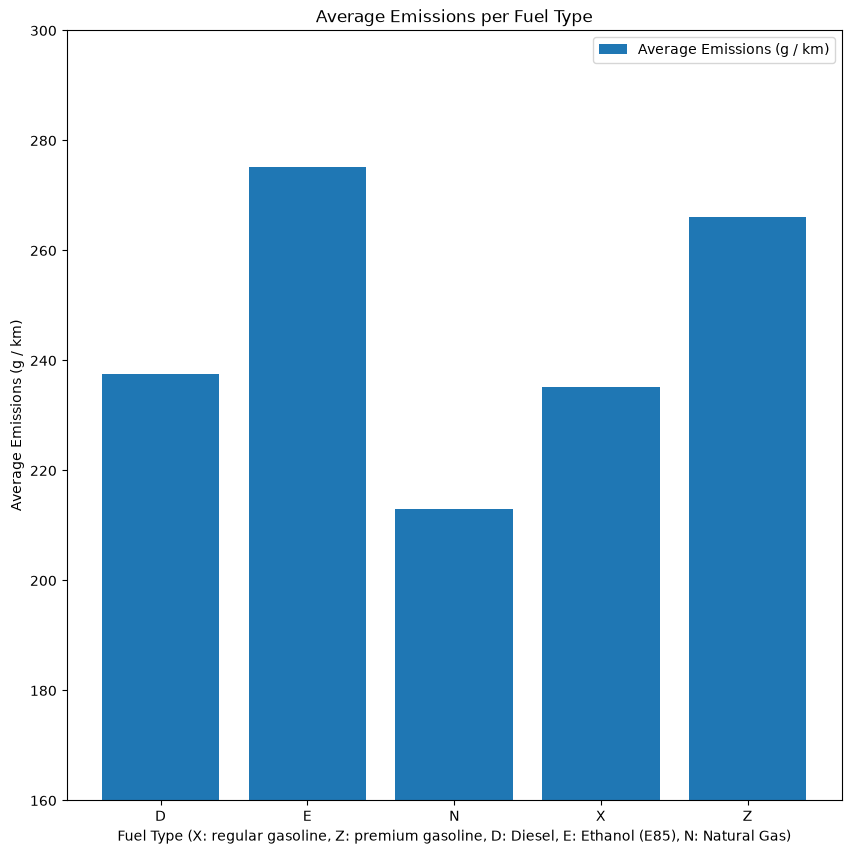

In [89]:
fig, ax = plt.subplots(figsize = (10, 10))
ax.bar(emissions_per_fueltype["Fuel Type"],
       emissions_per_fueltype["average_emission_per_fueltype"])
ax.set(xlabel = "Fuel Type (X: regular gasoline, Z: premium gasoline, D: Diesel, E: Ethanol (E85), N: Natural Gas)",
       ylabel = "Average Emissions (g / km)",
       title = "Average Emissions per Fuel Type",
       ylim = (160, 300))
ax.legend(["Average Emissions (g / km)"]);

In [51]:
df.dtypes

Make                                    str
Model                                   str
Vehicle Class                           str
Engine Size(L)                      float64
Cylinders                             int64
Transmission                            str
Fuel Type                               str
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object

In [56]:
df.select_dtypes(exclude = "number").columns

Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'], dtype='str')

These 5 columns in our DataFrame are of "string" datatype

Let's check the correlation between our numeric columns and the target column `CO2 Emissions (g/km)`

#### Correlation Matrix

> I'll use Seaborn's `heatmap` to make the correlation matrix more visually appealing.

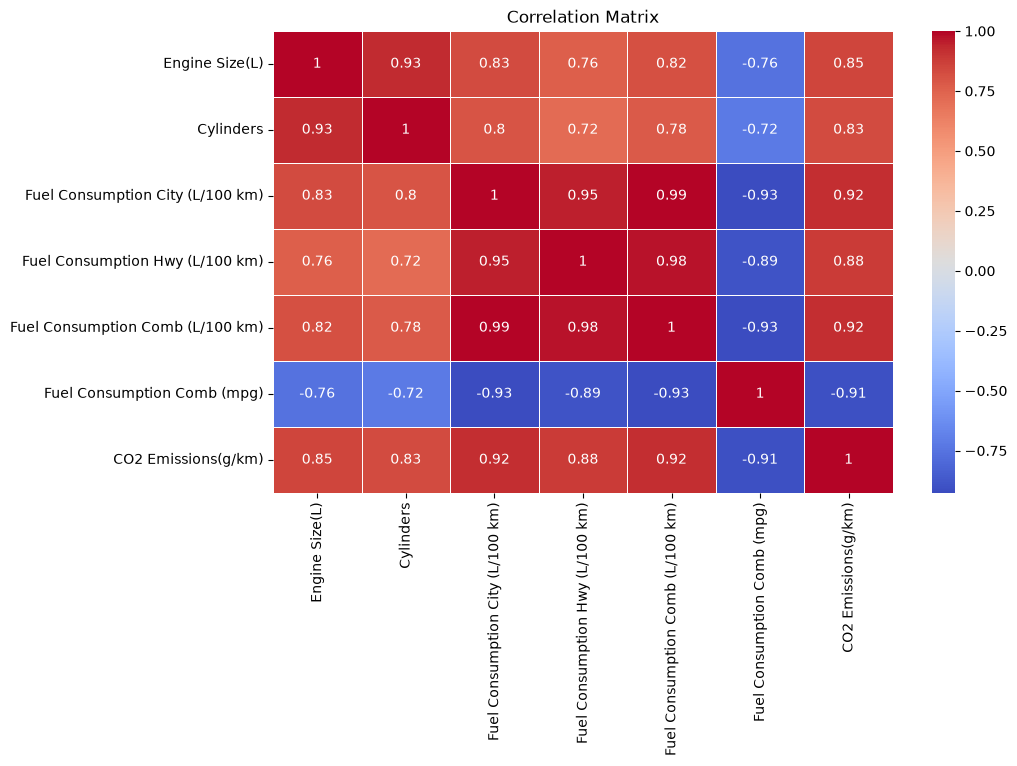

In [88]:
fig, ax = plt.subplots(figsize = (10, 6))
correlation_matrix = df.corr(numeric_only = True)
ax = sns.heatmap(correlation_matrix,
            annot = True,
            linewidths = 0.5,
            cmap = "coolwarm")
ax.set(title = "Correlation Matrix");

### Split Dataset into Features and Target

In [59]:
X = df.drop("CO2 Emissions(g/km)", axis = 1)
y = df["CO2 Emissions(g/km)"]

In [64]:
X

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27
...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29


In [63]:
y

0       196
1       221
2       136
3       255
4       244
       ... 
7380    219
7381    232
7382    240
7383    232
7384    248
Name: CO2 Emissions(g/km), Length: 7385, dtype: int64

In [66]:
X.shape, y.shape

((7385, 11), (7385,))

### Preprocessing our Data

Going to use Scikit-Learn's `Pipeline` to streamline the preprocessing process.

In [69]:
df.dtypes

Make                                    str
Model                                   str
Vehicle Class                           str
Engine Size(L)                      float64
Cylinders                             int64
Transmission                            str
Fuel Type                               str
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64
Fuel Consumption Comb (mpg)           int64
CO2 Emissions(g/km)                   int64
dtype: object

In [73]:
# Set random seed
np.random.seed(42)

# Define the different features (categorical / numerical)
categorical_features = ["Make", "Model", "Vehicle Class", "Transmission", "Fuel Type"]
numerical_features = ["Engine Size(L)", "Cylinders", "Fuel Consumption City (L/100 km)", "Fuel Consumption Hwy (L/100 km)",
                      "Fuel Consumption Comb (L/100 km)", "Fuel Consumption Comb (mpg)"]

# Define the two pipelines
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))
])

numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Join the 2 pipelines suing ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Create a preprocessing and modelling pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

# Split X and y into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Fit and Score the model
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9964058543750054

An R2-score of 0.99 is suspiciously high for a regression problem.

After looking back at the Correlation matrix heatmap:
> The `Fuel Consumption Columns` are extremely highly positively correlated with `CO2 Emissions(g/km)` - between 0.88 and 0.92 (the `Fuel Consumption Comb (mpg)` is extremely negatively correlated with the target column too)

This might be because, burning a fixed amount of fuel produces a near-fixed amount of CO2, from the physics of combustion.


So, I'll drop these columns from the feature set, and reframe the problem to **predicting CO2 emissions from vehicle specifictions alone**

### Modelling

In [93]:
# Rebuilding X and y
X = df.drop(["CO2 Emissions(g/km)", "Fuel Consumption City (L/100 km)",	"Fuel Consumption Hwy (L/100 km)",
             "Fuel Consumption Comb (L/100 km)", "Fuel Consumption Comb (mpg)"], axis = 1)
y = df["CO2 Emissions(g/km)"]

In [96]:
X.shape, y.shape

((7385, 7), (7385,))

In [99]:
# Set random seed
np.random.seed(42)

# Define the different features (categorical / numerical)
categorical_features = ["Make", "Model", "Vehicle Class", "Transmission", "Fuel Type"]
# Trimming the numerical_features from the pipeline
numerical_features = ["Engine Size(L)", "Cylinders"]

# Define the two pipelines
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))
])

numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Join the 2 pipelines suing ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Create a preprocessing and modelling pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

# Split X and y into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Fit and Score the model
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9647226470977411

### Hyperparameter Tuning with RandomizedSearchCV

In [104]:
%%time
# Create a Dictionary / Grid of Hyperparamters to change:
param_grid = {
    "model__n_estimators": np.arange(10, 100, 10),
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": np.arange(2, 20, 2),
    "model__min_samples_leaf": np.arange(1, 10, 1)
}

rs_model = RandomizedSearchCV(model,
                              param_distributions = param_grid,
                              n_jobs = -1,
                              cv = 5,
                              verbose = True,
                              n_iter = 100,
                              random_state = 42)

rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 2min 33s
Wall time: 3min 7s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': array([1, 2, ..., 6, 7, 8, 9]), 'model__min_samples_split': array([ 2, 4..., 14, 16, 18]), ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inch

In [105]:
rs_model.best_params_

{'model__n_estimators': np.int64(90),
 'model__min_samples_split': np.int64(4),
 'model__min_samples_leaf': np.int64(1),
 'model__max_features': 'sqrt',
 'model__max_depth': None}

In [106]:
rs_model.score(X_test, y_test)

0.9616510734928736